# **NBA Clutch Performance**

**Author:** Alejandro Magdiel Muniz Corona  
**Last updated:** 2026  
**Data source:** [nba_api](https://github.com/swar/nba_api)

## What is **'Clutch'**?

The NBA defines **clutch time** as the last **5 minutes** of the 4th quarter (or overtime) when the score difference is **5 points or less**. It measures a player's ability to perform when the **game is on the line**, the minutes that decide winners from losers

This notebook analyzes how players perform under that pressure:
- Who scores the most in clutch moments?
- Who shoots efficiently when it matters?
- Who handles the ball (assists vs turnovers)?
- How do clutch stats compare to overall season stats?

## Sections

1. [Setup & Imports](#1-setup--imports)
2. [Data Collection](#2-data-collection)
3. [Data Cleaning & Preparation](#3-data-cleaning--preparation)
4. [Exploratory Analysis](#4-exploratory-analysis)
5. [Clutch vs Overall Stats Comparison](#5-clutch-vs-overall-stats-comparison)
6. [Interactive Dashboard](#6-interactive-dashboard)
7. [Key Insights](#7-key-insights)

## 1. Setup & Imports

Install dependencies if needed, then import everything.

**First time?** Run this in your terminal before opening the notebook:

```bash
pip install nba_api pandas matplotlib seaborn plotly nbformat
```

Or directly inside a notebook cell:

```bash
!pip install nba_api pandas matplotlib seaborn plotly nbformat
```

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NBA API
from nba_api.stats.endpoints import leaguedashplayerclutch, leaguedashplayerstats

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'

## 2. Data Collection

We pull two datasets from the NBA Stats API:
- **Clutch stats**: player performance in clutch situations (last 5 min, ≤5 pt game)
- **Overall stats**: full season averages for comparison

In [2]:
SEASON = '2025-26' # Define the season to analyze

print(f'Fetching clutch stats for {SEASON} season...')

# Clutch stats
# Calling the API to get clutch stats for players in the specified season. 
# 'PerGame' mode is used to get per game averages, which allows for better comparability between players with different amounts of playing time.
clutch_response = leaguedashplayerclutch.LeagueDashPlayerClutch(
    season=SEASON,
    per_mode_detailed='PerGame',
)

# Extracting the clutch data into a DataFrame and printing its shape to understand how many players and statistics are included in the dataset.
df_clutch = clutch_response.get_data_frames()[0]
print(f'  Clutch data: {df_clutch.shape[0]} players, {df_clutch.shape[1]} columns')

Fetching clutch stats for 2025-26 season...
  Clutch data: 492 players, 68 columns


In [3]:
# Overall season stats
# Calling the API to get overall season stats for players in the specified season.
print(f'Fetching overall season stats for {SEASON}...')
overall_response = leaguedashplayerstats.LeagueDashPlayerStats(
    season=SEASON,
    per_mode_detailed='PerGame',
)

# Extracting the overall season data into a DataFrame and printing its shape to understand how many players and statistics are included in the dataset.
df_overall = overall_response.get_data_frames()[0]
print(f'  Overall data: {df_overall.shape[0]} players, {df_overall.shape[1]} columns')


Fetching overall season stats for 2025-26...
  Overall data: 582 players, 67 columns


Apparently, there is a column that is in the clutch stats dataframe ('df_clutch'), but it's not in the overall season stats ('df_overal').

In [4]:
# Checking for columns that are present in the clutch stats but not in the overall season stats. 
# This is important to understand if there are any unique statistics that are only available in the clutch dataset, which could be crucial for our analysis.
for col in df_clutch.columns:
    if col not in df_overall.columns:
        print(f'Column "{col}" is in clutch stats but not in overall stats.')


Column "GROUP_SET" is in clutch stats but not in overall stats.


Analysis of the possible values for this column:

In [5]:
df_clutch['GROUP_SET'].unique()

<StringArray>
['Players']
Length: 1, dtype: str

The column has only one possible value, which indicates it's not important for this analysis.

Now the retrieved data is analyzed.

In [6]:
# Quick look at the raw data
print('Clutch stats columns:')
print(df_clutch.columns.tolist())

Clutch stats columns:
['GROUP_SET', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT']


In [7]:
print('\nSample rows from clutch stats:')
df_clutch[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN', 'FGA', 'FGM', 'FG_PCT', 'PTS', 'REB', 'AST', 'TOV', 'PLUS_MINUS', 'W_PCT']].head(10)


Sample rows from clutch stats:


,PLAYER_NAME,TEAM_ABBREVIATION,GP,MIN,FGA,FGM,FG_PCT,PTS,REB,AST,TOV,PLUS_MINUS,W_PCT
0,A.J. Lawson,TOR,2,0.3,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.5,0.500
1,AJ Green,MIL,28,3.5,1.0,0.3,0.259,0.9,0.2,0.0,0.1,0.5,0.500
2,AJ Johnson,DAL,3,3.0,1.3,0.3,0.250,0.7,0.3,0.7,0.0,0.0,0.333
3,Aaron Gordon,DEN,14,5.2,2.1,1.2,0.586,3.4,0.8,0.4,0.2,1.8,0.643
4,Aaron Holiday,HOU,18,1.3,0.5,0.1,0.222,0.5,0.1,0.2,0.1,-1.3,0.556
5,Aaron Nesmith,IND,20,3.5,1.2,0.5,0.391,1.3,0.9,0.2,0.1,-0.5,0.400
6,Aaron Wiggins,OKC,17,2.0,0.5,0.2,0.375,0.6,0.3,0.1,0.1,0.0,0.647
7,Ace Bailey,UTA,21,2.8,0.9,0.4,0.444,0.9,0.5,0.2,0.2,-1.0,0.286
8,Adama Bal,MEM,1,5.3,1.0,1.0,1.000,3.0,1.0,1.0,0.0,3.0,1.000
9,Adem Bona,PHI,16,3.3,0.3,0.2,0.600,0.5,0.5,0.1,0.1,0.9,0.563


In [8]:
# Quick look at the raw data
print('Overall stats columns:')
print(df_overall.columns.tolist())

Overall stats columns:
['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT']


In [9]:
print('\nSample rows from overall stats:')
df_overall[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN', 'FGA', 'FGM', 'FG_PCT', 'PTS', 'REB', 'AST', 'TOV', 'PLUS_MINUS', 'W_PCT']].head(10)


Sample rows from overall stats:


,PLAYER_NAME,TEAM_ABBREVIATION,GP,MIN,FGA,FGM,FG_PCT,PTS,REB,AST,TOV,PLUS_MINUS,W_PCT
0,A.J. Lawson,TOR,24,9.4,3.3,1.4,0.436,4.2,1.8,0.3,0.3,-0.4,0.500
1,AJ Green,MIL,78,29.1,7.9,3.4,0.424,10.4,2.7,1.9,1.0,-1.9,0.397
2,AJ Johnson,DAL,48,9.4,3.7,1.2,0.324,3.3,1.1,1.0,0.6,-1.1,0.188
3,Aaron Gordon,DEN,36,27.9,11.1,5.5,0.497,16.2,5.8,2.7,1.1,7.6,0.750
4,Aaron Holiday,HOU,57,13.7,4.4,1.8,0.417,5.5,1.0,1.1,0.7,2.3,0.667
5,Aaron Nesmith,IND,45,29.7,11.4,4.7,0.414,13.8,4.2,1.9,1.4,-4.5,0.222
6,Aaron Wiggins,OKC,65,21.8,8.2,3.6,0.431,9.4,3.1,1.7,1.2,2.7,0.769
7,Ace Bailey,UTA,72,27.6,12.4,5.5,0.443,13.8,4.2,1.8,1.5,-6.2,0.264
8,Adama Bal,MEM,8,30.2,8.5,3.5,0.412,10.4,3.1,2.4,0.8,-20.8,0.125
9,Adem Bona,PHI,71,17.4,3.1,1.8,0.595,4.8,4.3,0.5,0.8,-0.1,0.577


## 3. Data Cleaning & Preparation

- Filter for players with meaningful clutch minutes
- Select relevant columns
- Merge clutch + overall into one dataframe for comparison

Text(0.5, 1.0, 'Distribution of Clutch Minutes Played')

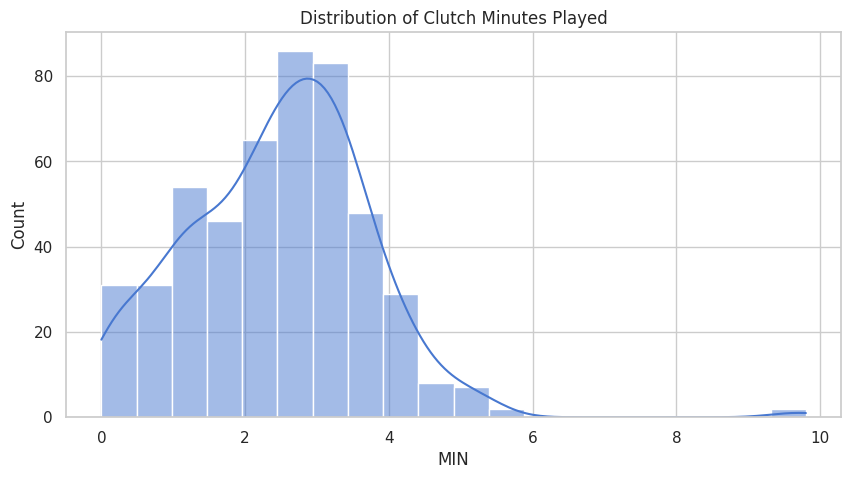

In [10]:
# Understanding the distribution of clutch minutes played across players to determine appropriate thresholds for filtering the dataset.
plt.figure(figsize=(10, 5))
sns.histplot(df_clutch['MIN'], bins=20, kde=True)
plt.title('Distribution of Clutch Minutes Played')

In [11]:
df_clutch['MIN'].describe()

count    492.000000
mean       2.463008
std        1.276871
min        0.000000
25%        1.500000
50%        2.500000
75%        3.300000
max        9.800000
Name: MIN, dtype: float64

Text(0.5, 1.0, 'Distribution of Clutch Games Played')

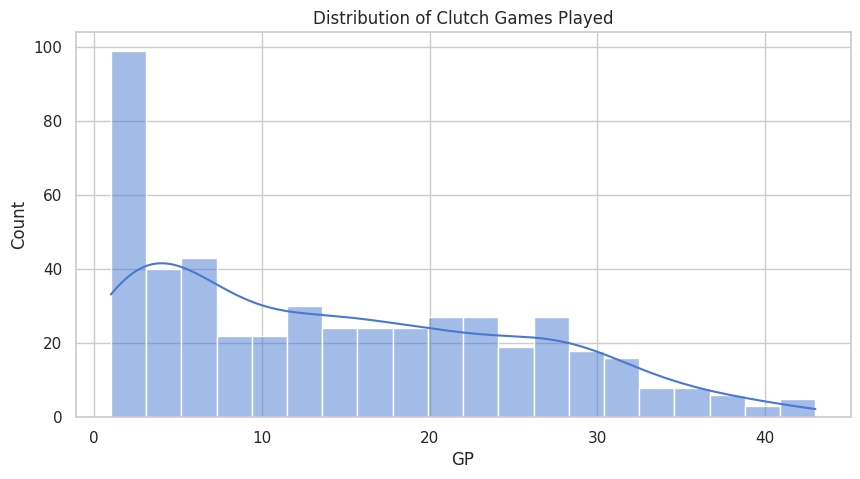

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clutch['GP'], bins=20, kde=True)
plt.title('Distribution of Clutch Games Played')

In [13]:
df_clutch['GP'].describe()

count    492.000000
mean      14.542683
std       10.858477
min        1.000000
25%        5.000000
50%       13.000000
75%       23.000000
max       43.000000
Name: GP, dtype: float64

**Feature Engineering**:
- Assist-to-turnover ratio (`AST_TOV_RATIO`): Assists divided by turnovers. Measures ball security and decision-making. A ratio of 2.0 means a player creates 2 assists for every 1 turnover. Higher = smarter with the ball under pressure.
- True shooting (`TRUE_SHOOTING`): Shooting efficiency accounting for 2s, 3s, and free throws. More complete than FG% alone.
- Points per minute in the clutch (`CLUTCH_PPM`): Points scored per minute exclusively in clutch situations (last 5 min, ≤5 pt game). Normalizes scoring to account for the short clutch time window.
- Points per minute overall (`OVR_PPM`): Points scored per minute across the full season. Used as the baseline to compare against clutch performance.
- Points clutch efficiency ratio (`PTS_CER`): CLUTCH_PPM divided by OVR_PPM. A value of 1.0 means the player scores at the same rate in clutch as overall. Above 1.0 = elevates under pressure. Below 1.0 = shrinks.
- Field goal percentage ratio (`FG_PCT_RATIO`): Clutch FG% divided by overall FG%. Same logic as PTS_CER but measuring shooting accuracy instead of scoring volume. Above 1.0 = shoots better when the game is on the line.

In [14]:
# Clean clutch data
# Focus on players with a minimum amount of clutch games played and clutch minutes per game to ensure meaningful analysis
MIN_CLUTCH_MINUTES = 3 # Minimum minutes played per game in clutch situations to be included in the analysis
MIN_CLUTCH_GAMES = 15 # Minimum games played in clutch situations to be included in the analysis

# Select relevant columns for analysis
clutch_cols = [
    'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION',
    'AGE', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT',
    'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT',
    'PTS', 'AST', 'TOV', 'REB', 'STL', 'BLK',
    'PLUS_MINUS', 'W', 'L', 'W_PCT'
]

df_c = df_clutch[clutch_cols].copy()

# Filter: minimum clutch minutes played and minimum clutch games played
df_c = df_c[(df_c['MIN'] >= MIN_CLUTCH_MINUTES) & (df_c['GP'] >= MIN_CLUTCH_GAMES)].reset_index(drop=True)

# New features
df_c['AST_TOV_RATIO'] = (df_c['AST'] / df_c['TOV'].replace(0, np.nan)).round(2)
df_c['TRUE_SHOOTING'] = (
    df_c['PTS'] / (2 * (df_c['FGA'] + 0.44 * df_c['FTA']))
).round(3)

print(f'Players with ≥{MIN_CLUTCH_MINUTES} clutch minutes and ≥{MIN_CLUTCH_GAMES} clutch games: {len(df_c)}')
df_c.head(5)

Players with ≥3 clutch minutes and ≥15 clutch games: 119


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,FGM,FGA,FG_PCT,FG3M,...,TOV,REB,STL,BLK,PLUS_MINUS,W,L,W_PCT,AST_TOV_RATIO,TRUE_SHOOTING
0,1631260,AJ Green,MIL,26.0,28,3.5,0.3,1.0,0.259,0.2,...,0.1,0.2,0.0,0.0,0.5,14,14,0.500,0.0,0.414
1,1630174,Aaron Nesmith,IND,26.0,20,3.5,0.5,1.2,0.391,0.2,...,0.1,0.9,0.1,0.2,-0.5,8,12,0.400,2.0,0.488
2,1641737,Adem Bona,PHI,23.0,16,3.3,0.2,0.3,0.600,0.0,...,0.1,0.5,0.0,0.3,0.9,9,7,0.563,1.0,0.579
3,1627936,Alex Caruso,OKC,32.0,19,3.3,0.3,1.1,0.286,0.3,...,0.1,0.8,0.3,0.1,1.8,14,5,0.737,3.0,0.409
4,1630578,Alperen Sengun,HOU,23.0,38,4.0,0.9,2.2,0.439,0.0,...,0.5,0.9,0.1,0.2,0.7,19,19,0.500,1.0,0.462


In [15]:
# Merge with overall stats to compute differentials
overall_cols = ['PLAYER_ID', 'PTS', 'MIN', 'FG_PCT', 'AST', 'TOV', 'PLUS_MINUS']
df_o = df_overall[overall_cols].copy()
df_o.columns = ['PLAYER_ID', 'OVR_PTS', 'OVR_MIN', 'OVR_FG_PCT', 'OVR_AST', 'OVR_TOV', 'OVR_PLUS_MINUS']

df = df_c.merge(df_o, on='PLAYER_ID', how='left')

# Points per minute
df['CLUTCH_PPM'] = (df['PTS'] / df['MIN']).round(4)
df['OVR_PPM']   = (df['OVR_PTS'] / df['OVR_MIN']).round(4)

# Clutch Efficiency Ratio (1.0 = same, >1.0 = better in clutch)
df['PTS_CER'] = (df['CLUTCH_PPM'] / df['OVR_PPM']).round(3)

# Same logic for FG%
df['FG_PCT_RATIO'] = (df['FG_PCT'] / df['OVR_FG_PCT']).round(3)


print(f'Merged dataset: {df.shape[0]} players')
df[['PLAYER_NAME', 'PTS', 'OVR_PTS', 'FG_PCT', 'CLUTCH_PPM', 'OVR_PPM','PTS_CER', 'FG_PCT_RATIO']].head(8)

Merged dataset: 119 players


,PLAYER_NAME,PTS,OVR_PTS,FG_PCT,CLUTCH_PPM,OVR_PPM,PTS_CER,FG_PCT_RATIO
0,AJ Green,0.9,10.4,0.259,0.2571,0.3574,0.719,0.611
1,Aaron Nesmith,1.3,13.8,0.391,0.3714,0.4646,0.799,0.944
2,Adem Bona,0.5,4.8,0.600,0.1515,0.2759,0.549,1.008
3,Alex Caruso,0.9,6.2,0.286,0.2727,0.3407,0.800,0.676
4,Alperen Sengun,2.4,20.4,0.439,0.6000,0.6126,0.979,0.846
5,Amen Thompson,1.7,18.3,0.510,0.4250,0.4893,0.869,0.955
6,Andrew Nembhard,1.5,16.9,0.438,0.4286,0.5399,0.794,0.991
7,Andrew Wiggins,1.9,15.4,0.583,0.5758,0.5083,1.133,1.227



## 4. Exploratory Analysis

### 4.1 Top clutch scorers

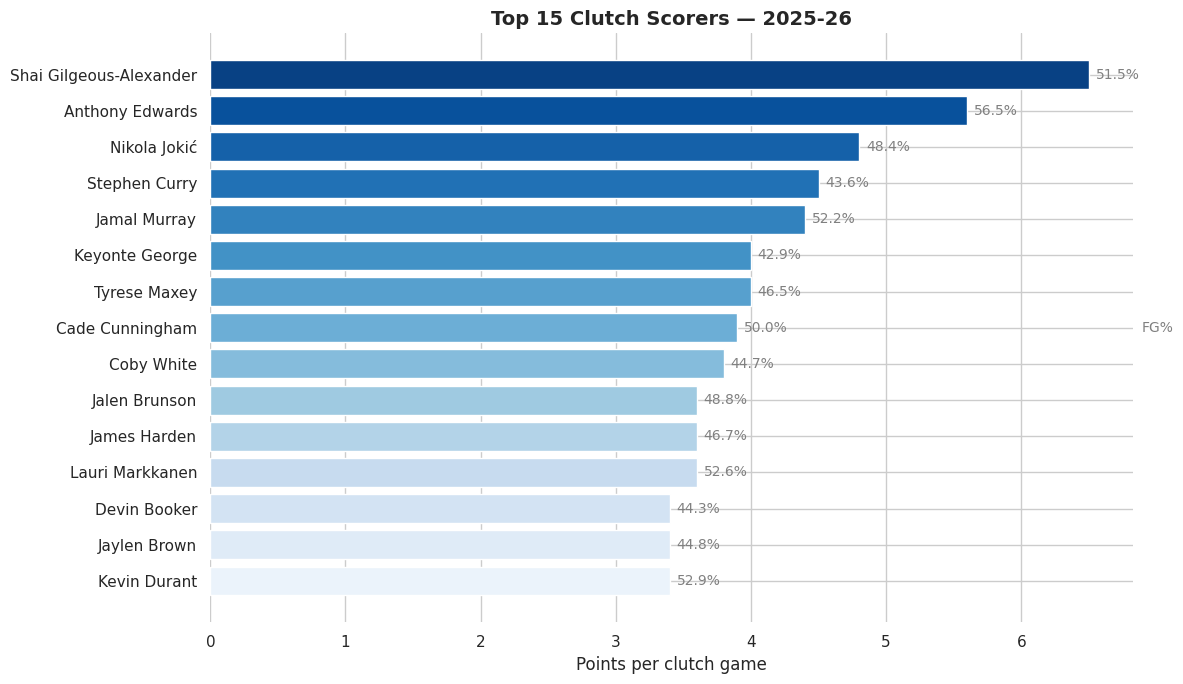

In [16]:
# ── 4.1 Top 15 Clutch Scorers ─────────────────────────────────────
top_scorers = df.nlargest(15, 'PTS')[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'PTS', 'FG_PCT']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_scorers['PLAYER_NAME'], top_scorers['PTS'],
               color=sns.color_palette('Blues_r', len(top_scorers)))

# Color bars by FG%
for bar, fg in zip(bars, top_scorers['FG_PCT']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{fg:.1%}', va='center', fontsize=10, color='gray')

ax.invert_yaxis()
ax.set_xlabel('Points per clutch game', fontsize=12)
ax.set_title(f'Top 15 Clutch Scorers — {SEASON}', fontsize=14, fontweight='bold')
ax.text(1.01, 0.5, 'FG%', transform=ax.transAxes, va='center', fontsize=10, color='gray')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('top_clutch_scorers.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 True shooting efficiency in clutch

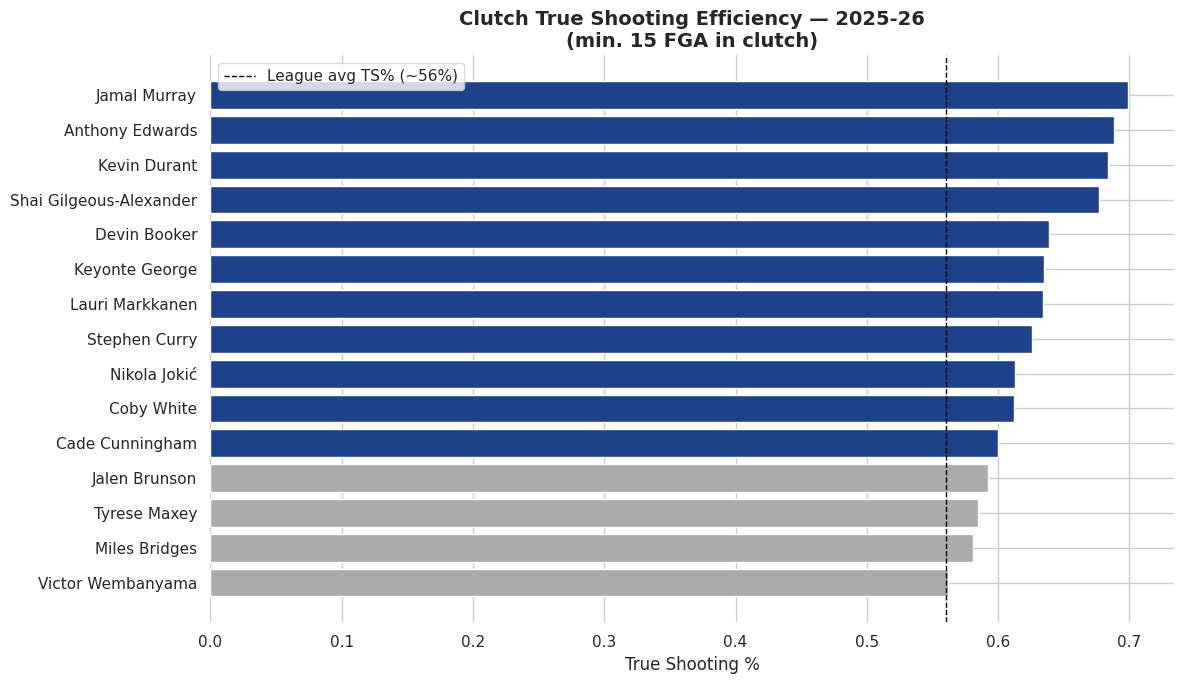

In [17]:
# ── 4.2 True Shooting Efficiency (min 15 clutch FGA) ─────────────
efficient = df[df['FGA'] >= 2].nlargest(15, 'TRUE_SHOOTING')

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#1d428a' if ts >= 0.60 else '#c8102e' if ts < 0.50 else '#aaaaaa'
          for ts in efficient['TRUE_SHOOTING']]
ax.barh(efficient['PLAYER_NAME'], efficient['TRUE_SHOOTING'], color=colors)
ax.axvline(0.56, color='black', linestyle='--', linewidth=1, label='League avg TS% (~56%)')
ax.invert_yaxis()
ax.set_xlabel('True Shooting %', fontsize=12)
ax.set_title(f'Clutch True Shooting Efficiency — {SEASON}\n(min. 15 FGA in clutch)', fontsize=14, fontweight='bold')
ax.legend()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('clutch_true_shooting.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Clutch +/- Leaders

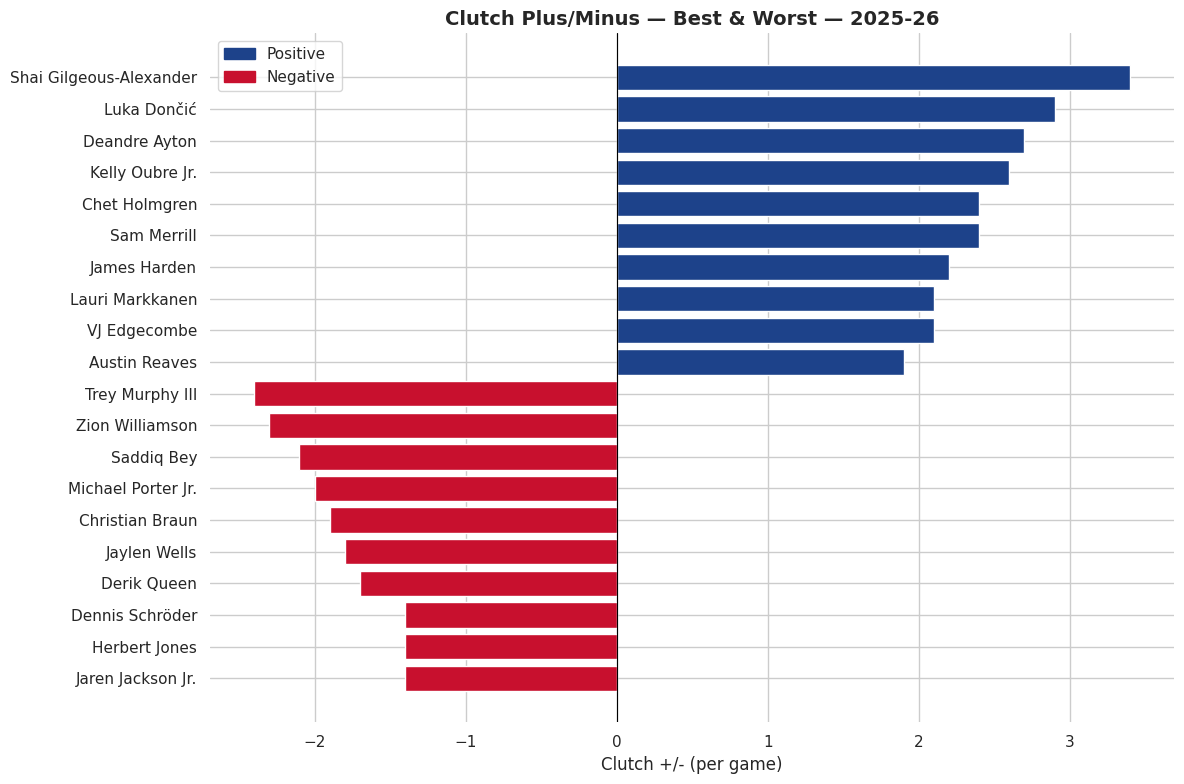

In [18]:
# ── 4.3 Clutch +/- Leaders ───────────────────────────────────────
pm_top    = df.nlargest(10, 'PLUS_MINUS')[['PLAYER_NAME', 'PLUS_MINUS', 'TEAM_ABBREVIATION']]
pm_bottom = df.nsmallest(10, 'PLUS_MINUS')[['PLAYER_NAME', 'PLUS_MINUS', 'TEAM_ABBREVIATION']]
pm_combined = pd.concat([pm_top, pm_bottom])

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#1d428a' if v > 0 else '#c8102e' for v in pm_combined['PLUS_MINUS']]
ax.barh(pm_combined['PLAYER_NAME'], pm_combined['PLUS_MINUS'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Clutch +/- (per game)', fontsize=12)
ax.set_title(f'Clutch Plus/Minus — Best & Worst — {SEASON}', fontsize=14, fontweight='bold')
pos_patch = mpatches.Patch(color='#1d428a', label='Positive')
neg_patch = mpatches.Patch(color='#c8102e', label='Negative')
ax.legend(handles=[pos_patch, neg_patch])
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('clutch_plus_minus.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Assist-to-turnover ratio

## 5. Clutch vs Overall Stats Comparison

Who **elevates** their game vs who **shrinks**? A positive differential means the player performs *better* in clutch than overall.

In [23]:
# ── Scatter: Clutch PTS vs Overall PTS ─────────────────────────
top20 = df.nlargest(20, 'PTS')

# Regression line: expected clutch PPG given overall PPG
from numpy.polynomial import polynomial as P
x = top20['OVR_PTS'].values
y = top20['PTS'].values
coefs = P.polyfit(x, y, 1)          # [intercept, slope]
x_line = np.linspace(x.min() - 1, x.max() + 1, 100)
y_line = P.polyval(x_line, coefs)

fig = px.scatter(
    top20,
    x='OVR_PTS', y='PTS',
    text='PLAYER_NAME',
    color='PTS_CER',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    size='MIN',
    hover_data=['TEAM_ABBREVIATION', 'FG_PCT', 'TRUE_SHOOTING'],
    title=f'Clutch PTS vs Overall PTS — Top 20 Clutch Scorers ({SEASON})',
    labels={'OVR_PTS': 'Overall PPG', 'PTS': 'Clutch PPG', 'PTS_DIFF': 'Clutch uplift'}
)

# Regression reference line
fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode='lines',
    line=dict(color='steelblue', dash='dash', width=1.5),
    name='Expected clutch PPG',
    showlegend=True
))

fig.update_layout(
    height=520,
    template='plotly_white',
    legend=dict(
        x=0.01, y=0.99,          # top-left corner
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.7)',
        borderwidth=0
    )
)

fig.update_traces(textposition='top center', textfont_size=9,
                  selector=dict(mode='markers+text'))

# Clamp y-axis tightly to data range
y_pad = 0.8
fig.update_yaxes(range=[top20['PTS'].min() - y_pad,
                         top20['PTS'].max() + y_pad])

fig.update_layout(height=520, template='plotly_white')
fig.write_html('clutch_vs_overall_ppm_scatter.html')
fig.show()



In [24]:
# Bar chart: Clutch Efficiency Ratio: Clutch PPM / Overall PPM 
diff_top = df.nlargest(15, 'PTS_CER')[['PLAYER_NAME', 'PTS_CER', 'TEAM_ABBREVIATION']]
diff_bot = df.nsmallest(10, 'PTS_CER')[['PLAYER_NAME', 'PTS_CER', 'TEAM_ABBREVIATION']]
diff_df  = pd.concat([diff_top, diff_bot])

fig = px.bar(
    diff_df.sort_values('PTS_CER'),
    x='PTS_CER', y='PLAYER_NAME',
    orientation='h',
    color='PTS_CER',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=1,
    hover_data=['TEAM_ABBREVIATION'],
    title=f'Clutch Efficiency Ratio: Clutch PPM / Overall PPM ({SEASON})',
    labels={'PTS_CER': 'Clutch efficiency ratio', 'PLAYER_NAME': ''}
)
fig.add_vline(x=1, line_color='black', line_width=0.8)
fig.update_layout(height=700, template='plotly_white', showlegend=False,
                  coloraxis_showscale=False)
fig.write_html('clutch_efficiency_ratio.html')
fig.show()

## 6. Interactive Dashboard

A combined multi-panel Plotly dashboard saved as a standalone HTML file you can share.

In [26]:
# ── Multi-panel dashboard ─────────────────────────────────────────
top_n = 15
df_dash = df.nlargest(top_n, 'PTS').sort_values('PTS')

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        f'Top {top_n} Clutch Scorers (PPG)',
        'Clutch FG% vs True Shooting %',
        'Clutch Efficiency Ratio (PPM clutch / PPM overall)',
        'Assist / Turnover Ratio'
    ),
    vertical_spacing=0.14
)

# Panel 1 — Top clutch scorers
fig.add_trace(go.Bar(
    x=df_dash['PTS'], y=df_dash['PLAYER_NAME'],
    orientation='h', marker_color='#1d428a',
    hovertemplate='%{y}: %{x:.1f} PPG<extra></extra>',
    name='Clutch PPG'
), row=1, col=1)

# Panel 2 — FG% vs TS%
fig.add_trace(go.Scatter(
    x=df_dash['FG_PCT'], y=df_dash['TRUE_SHOOTING'],
    mode='markers+text', text=df_dash['PLAYER_NAME'],
    textposition='top center', textfont=dict(size=8),
    marker=dict(size=10, color='#c8102e'),
    hovertemplate='%{text}<br>FG%: %{x:.1%}<br>TS%: %{y:.1%}<extra></extra>',
    name='FG% vs TS%'
), row=1, col=2)

# Panel 3 — Clutch Efficiency Ratio (elevators vs shrinkers)
cer_df = df_dash.sort_values('PTS_CER')
fig.add_trace(go.Bar(
    x=cer_df['PTS_CER'], y=cer_df['PLAYER_NAME'],
    orientation='h',
    marker=dict(
        color=cer_df['PTS_CER'],
        colorscale='RdBu',
        cmid=1,
        showscale=False
    ),
    hovertemplate='%{y}<br>CER: %{x:.3f}<extra></extra>',
    name='Clutch Efficiency Ratio'
), row=2, col=1)
fig.add_vline(x=1, line_color='black', line_width=0.8, row=2, col=1)

# Panel 4 — AST/TOV ratio
ast_df = df_dash.dropna(subset=['AST_TOV_RATIO']).sort_values('AST_TOV_RATIO')
fig.add_trace(go.Bar(
    x=ast_df['AST_TOV_RATIO'], y=ast_df['PLAYER_NAME'],
    orientation='h', marker_color='#008348',
    hovertemplate='%{y}: %{x:.2f}<extra></extra>',
    name='AST/TOV'
), row=2, col=2)

fig.update_layout(
    height=850,
    title_text=f'NBA Clutch Performance Dashboard — {SEASON}',
    title_font_size=18,
    template='plotly_white',
    showlegend=False
)

fig.write_html('nba_clutch_dashboard.html')
print('Dashboard saved as nba_clutch_dashboard.html')
fig.show()

Dashboard saved as nba_clutch_dashboard.html


## 7. Key Insights


### Findings

- **Top clutch scorer:** `Shai Gilgeous-Alexander` averaged `6.5` PPG in clutch situations.
- **Most efficient shooter:** `Jamal Murray` posted the highest TS% (`70.6%`) among players with ≥15 clutch FGAs.
- **Best clutch +/-:** `Shai Gigleous-Alexander` at `+3.4` per game, suggesting their team consistently wins close games when he's on the floor.
- **Ball security in clutch:** `Shai Gigleous-Alexander` had the best AST/TOV ratio of `2.67`, making smart decisions under pressure.
- - **Biggest clutch elevator (CER):** `Anthony Edwards` had the highest Clutch Efficiency Ratio of `1.745`, meaning he scores 74% more points per minute in clutch situations than he does throughout the rest of the game, the clearest sign of a player who genuinely raises his level when it matters most.

### Limitations

- Sample sizes in clutch situations are small — stats can be volatile.
- Plus/minus is influenced by teammates and opponents, not just individual performance.
- Some players may play heavy clutch minutes on losing teams (skewing +/- downward despite good individual play).

### Possible next steps

- Add shot charts for top clutch scorers
- Compare clutch performance across multiple seasons
- Build a clutch score composite metric
- Add team-level clutch analysis

In [30]:
# Export clean dataset
export_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT',
    'MIN', 'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT',
    'TRUE_SHOOTING', 'AST', 'TOV', 'AST_TOV_RATIO', 'REB', 'STL', 'BLK',
    'PLUS_MINUS', 'CLUTCH_PPM', 'OVR_PPM', 'PTS_CER',
    'OVR_PTS', 'OVR_FG_PCT', 'FG_PCT_RATIO'
]
df[export_cols].to_csv('nba_clutch_stats.csv', index=False)
print(f'Clean dataset exported → nba_clutch_stats.csv ({len(df)} players)')

Clean dataset exported → nba_clutch_stats.csv (119 players)
